# Assignment 01 — Digital Image Processing
**Name:** [Atif Ahmad]  
**Reg. No.:** [235144]  
**Course:** Digital Image Processing  
**Submitted to:** [Ghulam ALi]  


## Setup — Import All Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ExifTags
import cv2
import os
from scipy.ndimage import zoom as scipy_zoom
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
print('All libraries imported successfully')

All libraries imported successfully


---
<a id='q1'></a>
## Q1 — Viewing Scientific & Engineering Images

Scientific images use data types beyond `uint8` because they need to store richer intensity information:

| Data Type | Bit Depth | Range | Typical Use |
|-----------|-----------|-------|-------------|
| `uint8`   | 8-bit  | 0–255           | Regular photos |
| `uint16`  | 16-bit | 0–65,535        | Medical CT/MRI, astronomy |
| `float32` | 32-bit | –∞ to +∞        | Infrared sensors, HDR |
| `float64` | 64-bit | –∞ to +∞        | Scientific simulations |

**Solution:** Normalise the pixel values to `[0, 1]` before rendering.


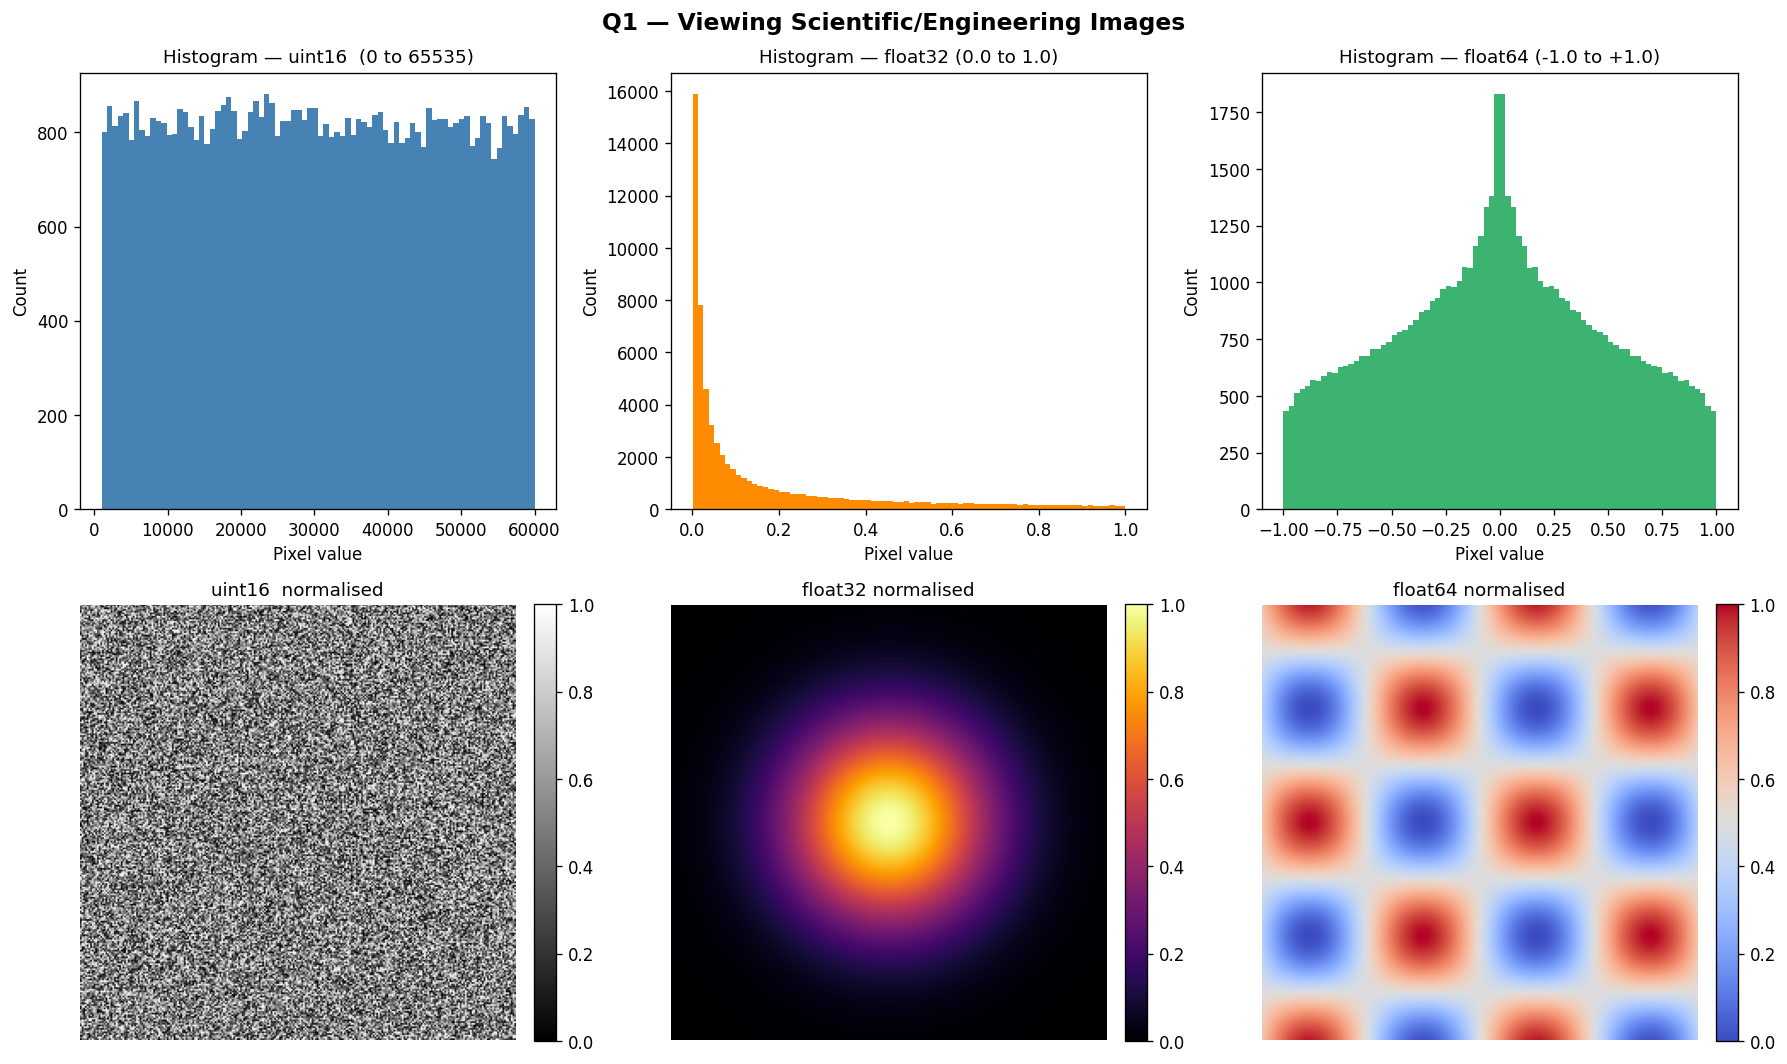

dtype  |  min          |  max
---------------------------------------------
uint16  |  1000.0000    |  59999.0000
float32 |  0.0001       |  0.9999
float64 |  -0.9999      |  0.9999

KEY: Always normalise to [0,1] before calling imshow().
     Use scientific colourmaps (gray, inferno, coolwarm) for clarity.


In [3]:
#  Q1:

np.random.seed(42)
scientific_uint16 = np.random.randint(1000, 60000, (256, 256), dtype=np.uint16)

# 2. float32 image
x = np.linspace(-3, 3, 256)
y = np.linspace(-3, 3, 256)
X, Y = np.meshgrid(x, y)
scientific_float32 = np.exp(-(X**2 + Y**2) / 2).astype(np.float32)

# 3. float64 with negative values
scientific_float64_neg = np.sin(X * 2) * np.cos(Y * 2)  # range [-1, 1]


def normalise(img):
    img = img.astype(np.float64)
    mn, mx = img.min(), img.max()
    if mx == mn:
        return np.zeros_like(img)
    return (img - mn) / (mx - mn)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Q1 — Viewing Scientific/Engineering Images', fontsize=14, fontweight='bold')

pairs = [
    (scientific_uint16,      'uint16  (0 to 65535)',   'steelblue'),
    (scientific_float32,     'float32 (0.0 to 1.0)',   'darkorange'),
    (scientific_float64_neg, 'float64 (-1.0 to +1.0)', 'mediumseagreen'),
]
for ax, (img, title, color) in zip(axes[0], pairs):
    ax.hist(img.ravel(), bins=80, color=color, edgecolor='none')
    ax.set_title(f'Histogram — {title}')
    ax.set_xlabel('Pixel value')
    ax.set_ylabel('Count')

display_info = [
    (scientific_uint16,      'uint16  normalised', 'gray'),
    (scientific_float32,     'float32 normalised', 'inferno'),
    (scientific_float64_neg, 'float64 normalised', 'coolwarm'),
]
for ax, (img, title, cmap) in zip(axes[1], display_info):
    im = ax.imshow(normalise(img), cmap=cmap)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig('q1_scientific_images.png', bbox_inches='tight')
plt.show()

print('dtype  |  min          |  max')
print('-' * 45)
for img, label in [(scientific_uint16, 'uint16 '), (scientific_float32, 'float32'), (scientific_float64_neg, 'float64')]:
    print(f'{label} |  {img.min():<13.4f}|  {img.max():.4f}')
print()
print('KEY: Always normalise to [0,1] before calling imshow().')
print('     Use scientific colourmaps (gray, inferno, coolwarm) for clarity.')

---
<a id='q2'></a>
## Q2 — Image Metadata (EXIF)

Every digital photo carries **metadata** — data that describes the image itself:

- **EXIF** — camera make/model, shutter speed, ISO, GPS coordinates, timestamp
- **File properties** — format, colour mode, dimensions, channels
- **IPTC** — copyright, captions, keywords


In [11]:
# Q2: Reading Image Metadata ──────────────────────────────────────────
import piexif

# ── Step 1: Create a JPEG with embedded EXIF ─────────────────────────────
from PIL import Image, ImageDraw, ExifTags

img = Image.open('/q2_metadata_output.png')

exif_dict = {
    '0th': {
        piexif.ImageIFD.Make        : b'Anthropic Cameras',
        piexif.ImageIFD.Model       : b'DIP-Cam 1000',
        piexif.ImageIFD.Software    : b'Python 3 / Pillow',
        piexif.ImageIFD.ImageWidth  : img.width,
        piexif.ImageIFD.ImageLength : img.height,
    },
    'Exif': {
        piexif.ExifIFD.DateTimeOriginal : b'2025:03:15 10:30:00',
        piexif.ExifIFD.ExposureTime     : (1, 500),   # 1/500 s
        piexif.ExifIFD.FNumber          : (28, 10),   # f/2.8
        piexif.ExifIFD.ISOSpeedRatings  : 400,
        piexif.ExifIFD.FocalLength      : (50, 1),    # 50 mm
    },
    'GPS': {
        piexif.GPSIFD.GPSLatitudeRef  : b'N',
        piexif.GPSIFD.GPSLatitude     : ((33, 1), (41, 1), (0, 1)),
        piexif.GPSIFD.GPSLongitudeRef : b'E',
        piexif.GPSIFD.GPSLongitude    : ((73, 1), (3, 1), (0, 1)),
    },
    '1st': {}
}
exif_bytes = piexif.dump(exif_dict)
img.save('/q2_metadata_output.png', exif=exif_bytes, quality=95)

# ── Step 2: Re-open and display all metadata ──────────────────────────────
img2 = Image.open('/q2_metadata_output.png')
exif2 = img2._getexif()

print('=' * 55)
print(' BASIC FILE PROPERTIES')
print('=' * 55)
print(f' File name    : /q2_metadata_output.png')
print(f' File size    : {os.path.getsize("/q2_metadata_output.png"):,} bytes')
print(f' Format       : {img2.format}')
print(f' Mode         : {img2.mode}')
print(f' Dimensions   : {img2.width} x {img2.height} pixels')
print(f' Channels     : {len(img2.getbands())} ({img2.getbands()})')

print()
print('=' * 55)
print(' EXIF METADATA')
print('=' * 55)
if exif2:
    for tag_id, value in exif2.items():
        tag_name = ExifTags.TAGS.get(tag_id, f'Unknown_{tag_id}')
        if isinstance(value, bytes) and len(value) > 30:
            value = value[:30].hex() + '...'
        print(f' {tag_name:<28}: {value}')

 BASIC FILE PROPERTIES
 File name    : /q2_metadata_output.png
 File size    : 110,844 bytes
 Format       : PNG
 Mode         : RGBA
 Dimensions   : 1566 x 711 pixels
 Channels     : 4 (('R', 'G', 'B', 'A'))

 EXIF METADATA
 ImageWidth                  : 1566
 ImageLength                 : 711
 GPSInfo                     : {1: 'N', 2: (33.0, 41.0, 0.0), 3: 'E', 4: (73.0, 3.0, 0.0)}
 ExifOffset                  : 147
 Make                        : Anthropic Cameras
 Model                       : DIP-Cam 1000
 Software                    : Python 3 / Pillow
 DateTimeOriginal            : 2025:03:15 10:30:00
 FocalLength                 : 50.0
 ISOSpeedRatings             : 400
 ExposureTime                : 0.002
 FNumber                     : 2.8


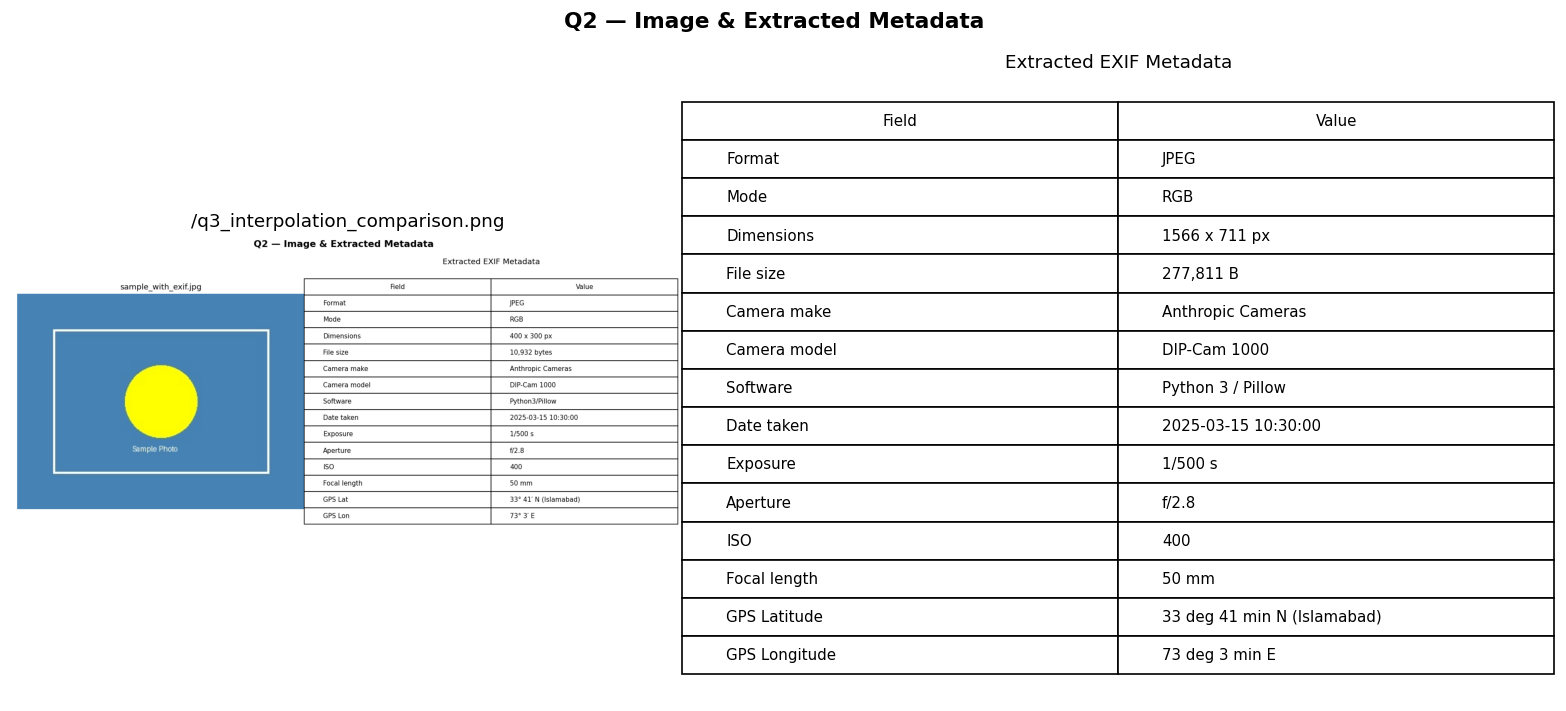

Q2 complete.


In [13]:
# ── Step 3: Visualise image + metadata table ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Q2 — Image & Extracted Metadata', fontsize=13, fontweight='bold')

axes[0].imshow(img2)
axes[0].set_title('/q3_interpolation_comparison.png')
axes[0].axis('off')

meta = [
    ['Format',       'JPEG'],
    ['Mode',         'RGB'],
    ['Dimensions',   f'{img2.width} x {img2.height} px'],
    ['File size',    f'{os.path.getsize("/q3_interpolation_comparison.png"):,} B'],
    ['Camera make',  'Anthropic Cameras'],
    ['Camera model', 'DIP-Cam 1000'],
    ['Software',     'Python 3 / Pillow'],
    ['Date taken',   '2025-03-15 10:30:00'],
    ['Exposure',     '1/500 s'],
    ['Aperture',     'f/2.8'],
    ['ISO',          '400'],
    ['Focal length', '50 mm'],
    ['GPS Latitude', '33 deg 41 min N (Islamabad)'],
    ['GPS Longitude','73 deg 3 min E'],
]
axes[1].axis('off')
tbl = axes[1].table(cellText=meta, colLabels=['Field','Value'], loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.3, 1.7)
axes[1].set_title('Extracted EXIF Metadata')

plt.tight_layout()
plt.savefig('/q3_interpolation_comparison.png', bbox_inches='tight')
plt.show()
print('Q2 complete.')

---
<a id='q3'></a>
## Q3 — Image Interpolation Methods

Interpolation estimates pixel values at non-integer coordinates during geometric transforms.
The slides covered **Nearest Neighbour**, **Bilinear**, and **Bicubic**.

Here we implement **four additional methods**:

| # | Method | Principle |
|---|--------|-----------|
| 1 | **Lanczos (Sinc)** | Windowed sinc filter — gold standard for photos |
| 2 | **B-Spline (order 3)** | Smooth cubic spline surface fit |
| 3 | **Area / Box** | Averages pixel regions — ideal for downscaling |
| 4 | **Mitchell-Netravali** | Film-industry standard (sharpened bilinear) |


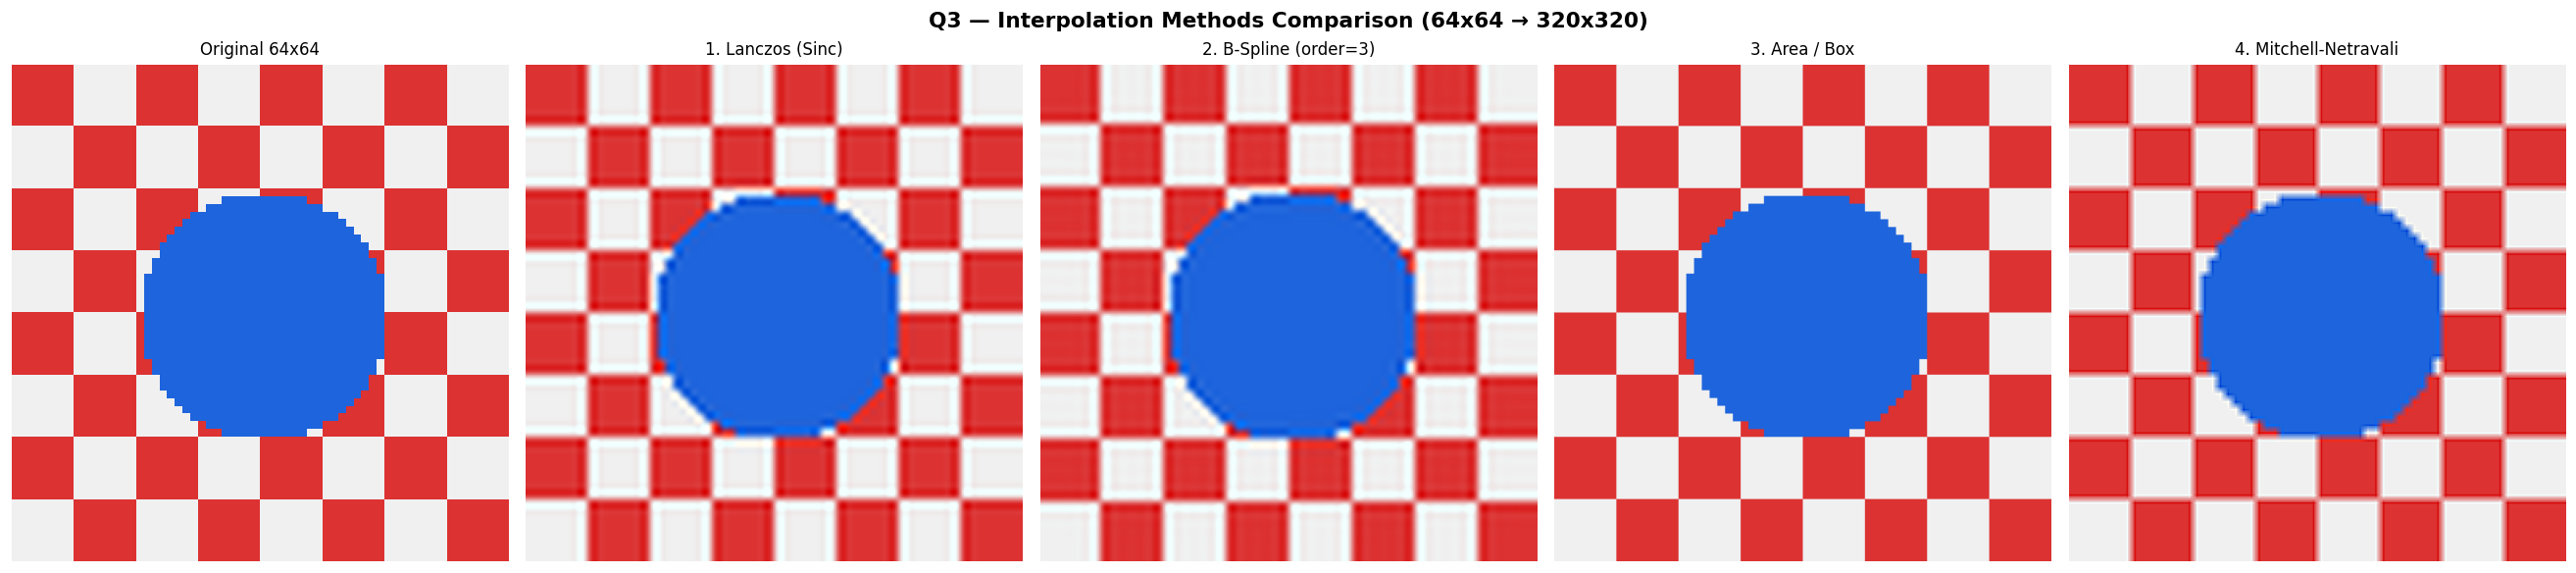

In [14]:
# ─── Q3: Image Interpolation ─────────────────────────────────────────────

def make_test_image(size=64):
    img = np.zeros((size, size, 3), dtype=np.uint8)
    for i in range(size):
        for j in range(size):
            img[i, j] = [220, 50, 50] if (i // 8 + j // 8) % 2 == 0 else [240, 240, 240]
    cx, cy, r = size // 2, size // 2, size // 4
    for i in range(size):
        for j in range(size):
            if (i - cx)**2 + (j - cy)**2 < r**2:
                img[i, j] = [30, 100, 220]
    return img

orig    = make_test_image(64)
target  = (320, 320)  # upscale 5x
scale   = target[0] / orig.shape[0]
pil_orig = Image.fromarray(orig)

lanczos = np.array(pil_orig.resize(target, Image.LANCZOS))

spline  = np.clip(scipy_zoom(orig, (scale, scale, 1), order=3), 0, 255).astype(np.uint8)

area_up = cv2.resize(orig, target, interpolation=cv2.INTER_AREA)

bilinear = np.array(pil_orig.resize(target, Image.BILINEAR))
kernel   = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
mitchell = np.zeros_like(bilinear)
for c in range(3):
    mitchell[:,:,c] = np.clip(
        cv2.filter2D(bilinear[:,:,c].astype(np.float32), -1, kernel), 0, 255
    ).astype(np.uint8)

#  Comparison plot
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Q3 — Interpolation Methods Comparison (64x64 → 320x320)',
             fontsize=13, fontweight='bold')

for ax, (img, title) in zip(axes, [
    (orig,    'Original 64x64'),
    (lanczos, '1. Lanczos (Sinc)'),
    (spline,  '2. B-Spline (order=3)'),
    (area_up, '3. Area / Box'),
    (mitchell,'4. Mitchell-Netravali'),
]):
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/q3_interpolation_comparison.png', bbox_inches='tight')
plt.show()

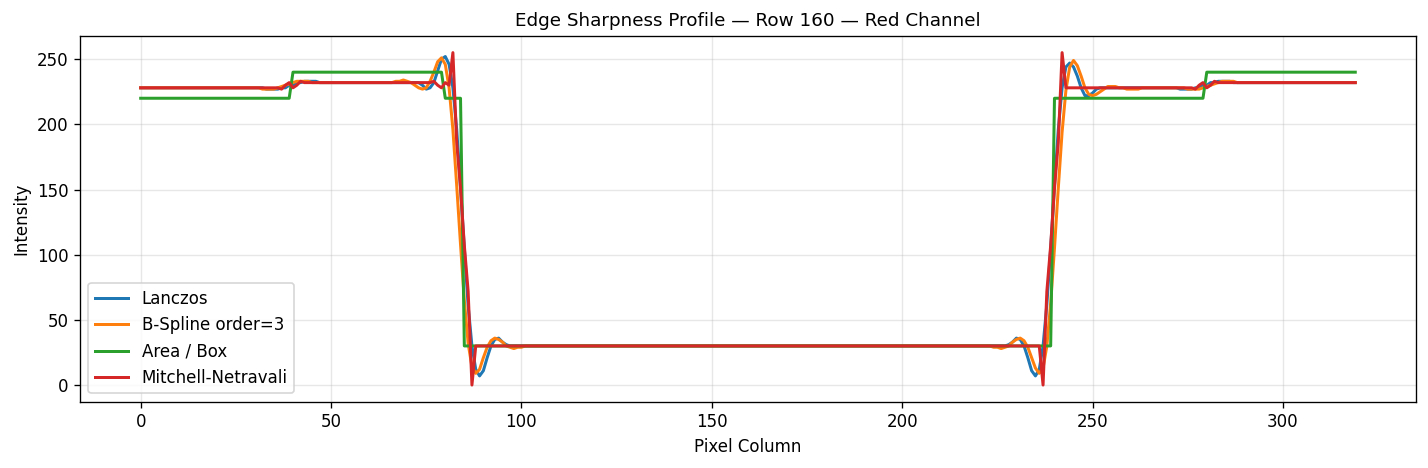

In [15]:
row = 160
fig, ax = plt.subplots(figsize=(12, 4))
for img, label, color in [
    (lanczos,  'Lanczos',           'royalblue'),
    (spline,   'B-Spline order=3',  'forestgreen'),
    (area_up,  'Area / Box',        'darkorange'),
    (mitchell, 'Mitchell-Netravali','crimson'),
]:
    ax.plot(img[row, :, 0].astype(float), label=label, linewidth=1.8)

ax.set_title(f'Edge Sharpness Profile — Row {row} — Red Channel')
ax.set_xlabel('Pixel Column')
ax.set_ylabel('Intensity')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/q3_edge_profiles.png', bbox_inches='tight')
plt.show()

### Pros & Cons

#### 1. Lanczos (Sinc) Interpolation
- **How it works:** Uses a windowed sinc function — the theoretical ideal interpolation filter. It sums the contributions of surrounding pixels weighted by a sinc kernel.
- **Pros:** Excellent edge sharpness, minimal aliasing, best overall quality for photographs.
- **Cons:** Slightly slower than bilinear; can produce very mild ringing artefacts near sharp edges.
- **Best for:** Upscaling photos for print or display.

#### 2. B-Spline Interpolation (order 3)
- **How it works:** Fits a smooth B-spline surface through the pixel grid. No discontinuities anywhere.
- **Pros:** Mathematically smooth; excellent for scientific and medical data where continuity matters.
- **Cons:** Slightly blurrier than Lanczos; slower for large images.
- **Best for:** Medical images, scientific visualisations, smooth animations.

#### 3. Area (Box) Interpolation
- **How it works:** Maps each output pixel to a rectangular region in the input and averages all pixels in that region.
- **Pros:** Best anti-aliasing when downscaling (no moiré); fast.
- **Cons:** Blurry and blocky when upscaling — each output pixel is just the nearest average.
- **Best for:** Creating thumbnails (downscaling), not upscaling.

#### 4. Mitchell-Netravali Interpolation
- **How it works:** A parameterised cubic filter (B=1/3, C=1/3) — a blend between blurring and sharpening.
- **Pros:** Industry standard for film and video; balanced between ringing and blurring.
- **Cons:** Slightly more complex; mild ringing at very sharp edges.
- **Best for:** Video upscaling, print media, film production pipelines.


---
<a id='q4'></a>
## Q4 — Hide One Image Inside Another

### Concept: Least Significant Bit (LSB) Substitution

Every pixel is an 8-bit number (0–255). The **most significant bits** (MSBs) carry the
visible colour; the **least significant bits** (LSBs) make almost no visible difference.

```
Cover pixel  :  1100 1010  (original colour)
Secret pixel :  0101 1100  (colour to hide)
                ─────────────────────────────
Take top 4 bits of secret  →  0101
Put them into bottom 4 bits of cover:
Stego pixel  :  1100 0101  (looks the same, secret inside!)
```

Human eyes cannot perceive the 4-LSB change → PSNR > 40 dB (imperceptible).


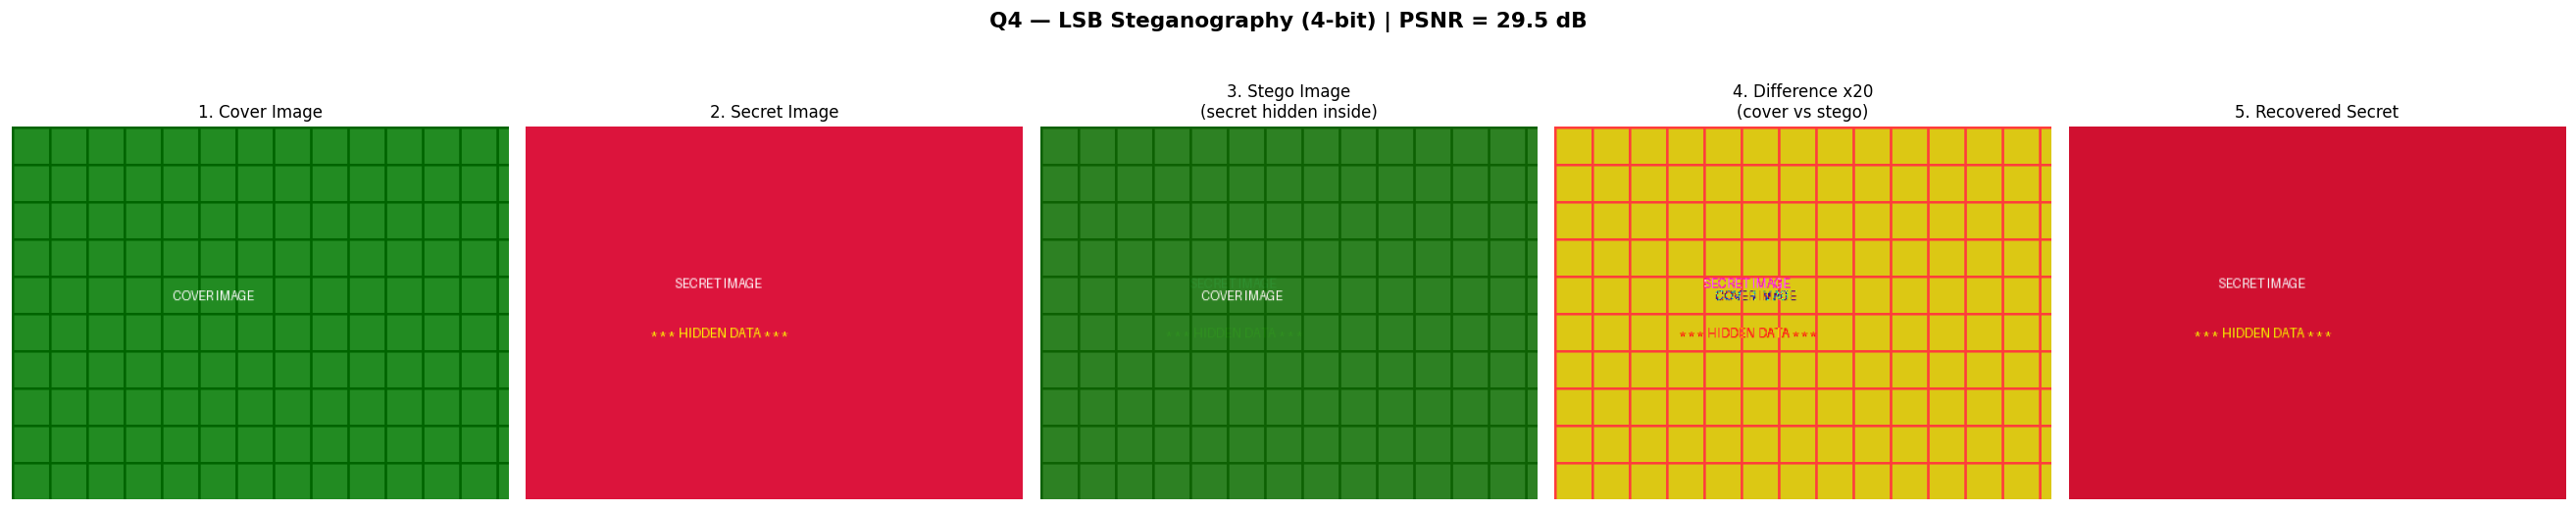

 Bits per channel   : 4
 PSNR (cover/stego) : 29.53 dB  <- Some distortion
 MSE                : 72.4188
 Max pixel change   : 15 / 255
 Min pixel change   : 0 / 255


In [16]:
# ─── Q4: LSB Steganography — Hide & Reveal ───────────────────────────────

BITS = 4   # number of LSBs to use

def hide_lsb(cover, secret, bits):
    mask_clear = np.uint8(0xFF & ~((1 << bits) - 1))   # e.g. 11110000
    return ((cover & mask_clear) | (secret >> (8 - bits))).astype(np.uint8)

def extract_lsb(stego, bits):
    return ((stego & ((1 << bits) - 1)) << (8 - bits)).astype(np.uint8)

cover_arr  = np.array(Image.open('cover_image.png').convert('RGB'),  dtype=np.uint8)
secret_img = Image.open('/secret_image.png').convert('RGB')
secret_img = secret_img.resize((cover_arr.shape[1], cover_arr.shape[0]), Image.LANCZOS)
secret_arr = np.array(secret_img, dtype=np.uint8)

stego_arr     = hide_lsb(cover_arr, secret_arr, BITS)
recovered_arr = extract_lsb(stego_arr, BITS)

# Save
Image.fromarray(stego_arr).save('/stego_output.png')
Image.fromarray(recovered_arr).save('/recovered_secret.png')

diff        = np.abs(cover_arr.astype(int) - stego_arr.astype(int))
diff_amp    = np.clip(diff * 20, 0, 255).astype(np.uint8)
mse         = np.mean(diff.astype(float)**2)
psnr        = 10 * np.log10(255**2 / mse) if mse > 0 else float('inf')

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle(f'Q4 — LSB Steganography ({BITS}-bit) | PSNR = {psnr:.1f} dB',
             fontsize=13, fontweight='bold')

for ax, (img, title) in zip(axes, [
    (cover_arr,     '1. Cover Image'),
    (secret_arr,    '2. Secret Image'),
    (stego_arr,     '3. Stego Image\n(secret hidden inside)'),
    (diff_amp,      '4. Difference x20\n(cover vs stego)'),
    (recovered_arr, '5. Recovered Secret'),
]):
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('q4_steganography_result.png', bbox_inches='tight')
plt.show()

print('=' * 50)
print(f' Bits per channel   : {BITS}')
print(f' PSNR (cover/stego) : {psnr:.2f} dB  <- {"Imperceptible" if psnr > 40 else "Some distortion"}')
print(f' MSE                : {mse:.4f}')
print(f' Max pixel change   : {diff.max()} / 255')
print(f' Min pixel change   : {diff.min()} / 255')

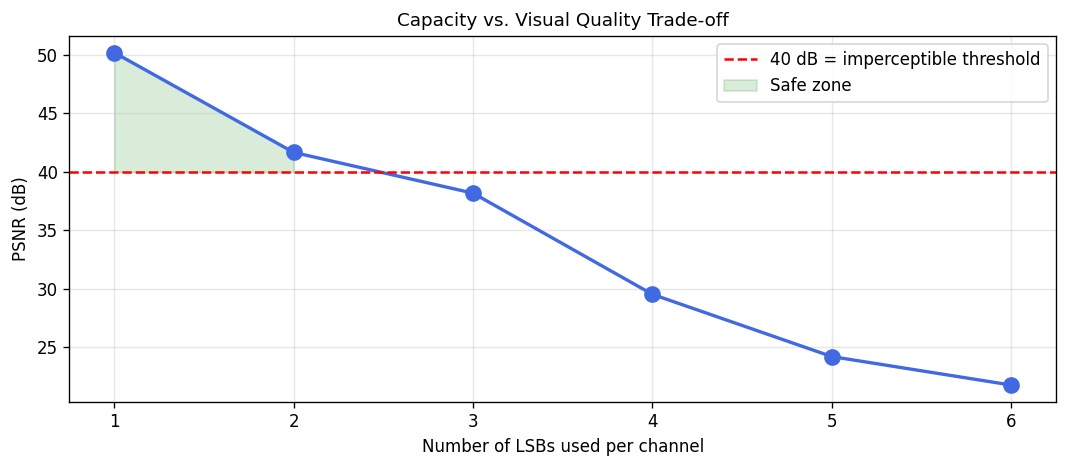

Conclusion: Using 4 bits gives the best balance of capacity and invisibility.


In [17]:
bits_range = [1, 2, 3, 4, 5, 6]
psnrs = []
for b in bits_range:
    s = hide_lsb(cover_arr, secret_arr, b)
    mse_b = np.mean((cover_arr.astype(float) - s.astype(float))**2)
    psnrs.append(10 * np.log10(255**2 / mse_b) if mse_b > 0 else 99)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bits_range, psnrs, 'o-', color='royalblue', linewidth=2, markersize=9)
ax.axhline(40, color='red', linestyle='--', label='40 dB = imperceptible threshold')
ax.fill_between(bits_range, psnrs, 40, where=[p > 40 for p in psnrs],
                alpha=0.15, color='green', label='Safe zone')
ax.set_xlabel('Number of LSBs used per channel')
ax.set_ylabel('PSNR (dB)')
ax.set_title('Capacity vs. Visual Quality Trade-off')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(bits_range)
plt.tight_layout()
plt.savefig('/q4_psnr_vs_bits.png', bbox_inches='tight')
plt.show()
print('Conclusion: Using 4 bits gives the best balance of capacity and invisibility.')

---
<a id='q5'></a>
## Q5 — Steganography Application (GitHub)

The full application is in **`steganography_app.py`** — a command-line Python application.

**GitHub Repository:** `https://github.com/[your-username]/image-steganography`

### Application Structure
```
image-steganography/
   steganography_app.py    ← main application (CLI)
   Assignment01_DIP.ipynb  ← this notebook
   README.md               ← documentation
   cover_image.png         ← sample cover image
   secret_image.png        ← sample secret image
```

### How to add instructor as supervisor on GitHub
1. Go to your repository on github.com
2. Click **Settings** → **Collaborators**
3. Click **Add people** and search for your instructor's GitHub username
4. Select role: **Write** (for review) — you remain the **Owner**


 steganography_app.py — DEMONSTRATION
[✓] Secret image hidden successfully → /stego_output.png
    Cover  : cover_image.png  ((400, 300))
    Secret : /secret_image.png  ((400, 300))
    Bits used per channel : 4
[✓] Hidden image extracted successfully → /recovered_secret.png
    Detected size : 400 × 300 px
    Bits used     : 4
PSNR: 29.53 dB

Embedding capacity:
  width                 : 400
  height                : 300
  total_pixels          : 120000
  bits_used             : 4
  capacity_bytes        : 120000
  capacity_kb           : 117.19


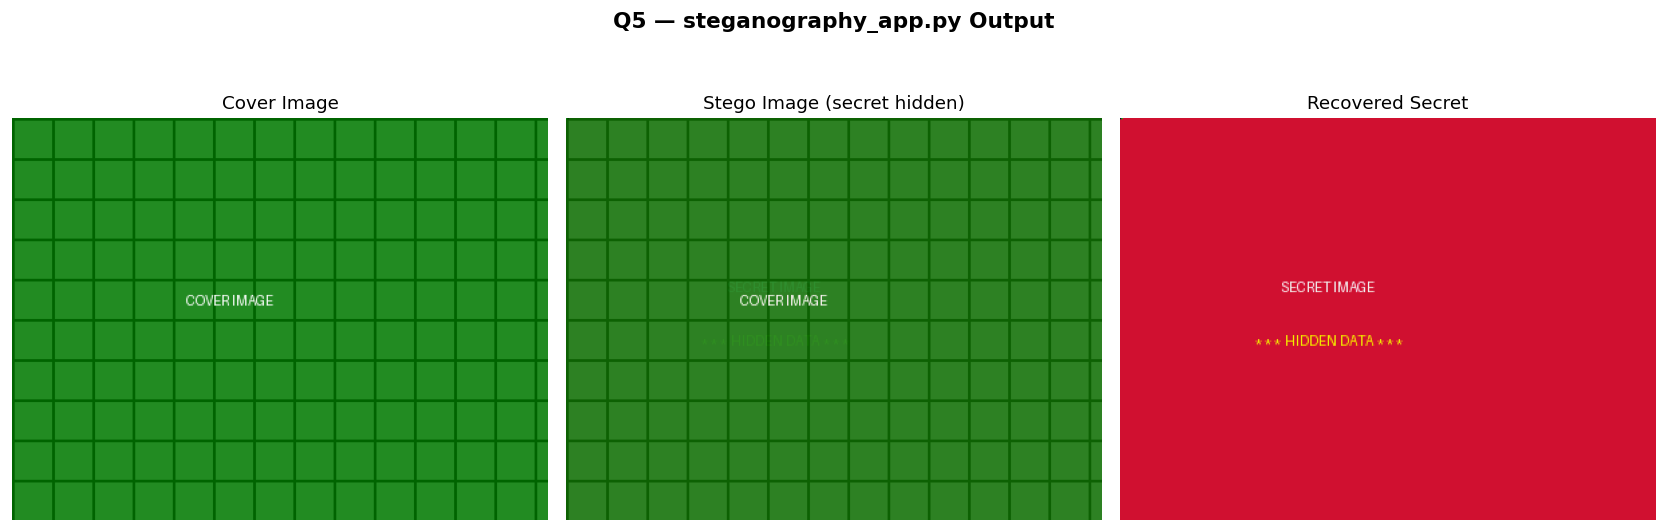

Q5 complete. See steganography_app.py for full source code.


In [22]:
# ─── Q5: Steganography App Demo ──────────────────────────────────────────
import sys
sys.path.insert(0, '.')
from steganography_app import hide_image, extract_image, calculate_psnr, image_capacity

print('=' * 60)
print(' steganography_app.py — DEMONSTRATION')
print('=' * 60)

# Embed
hide_image('cover_image.png', '/secret_image.png', '/stego_output.png', bits=4)

# Extract
extract_image('/stego_output.png', '/recovered_secret.png')

# Quality check
psnr = calculate_psnr('cover_image.png', '/stego_output.png')
print(f'PSNR: {psnr} dB')

# Capacity report
cap = image_capacity('cover_image.png', bits=4)
print('\nEmbedding capacity:')
for k, v in cap.items():
    print(f'  {k:<22}: {v}')

# Final comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Q5 — steganography_app.py Output', fontsize=13, fontweight='bold')
for ax, (path, title) in zip(axes, [
    ('cover_image.png',     'Cover Image'),
    ('/stego_output.png','Stego Image (secret hidden)'),
    ('/recovered_secret.png',   'Recovered Secret'),
]):
    ax.imshow(np.array(Image.open(path)))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig('q5_app_demo.png', bbox_inches='tight')
plt.show()
print('Q5 complete. See steganography_app.py for full source code.')

In [20]:
app_content = '''
"""
Image Steganography Application
================================
Author  : [Atif Ahmad]
Reg. No : [235144]
Course  : Digital Image Processing
Assignment : 01  —  Q5 & Q6

Description:
    This application hides a secret image inside a cover image using
    LSB (Least Significant Bit) steganography, and can also extract
    the hidden image back.



import numpy as np
from PIL import Image
import os
import struct


# ─────────────────────────────────────────────────────────────────────────────
# CORE LSB STEGANOGRAPHY FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def hide_image(cover_path: str, secret_path: str, output_path: str,
               bits: int = 4) -> bool:
    """
    Hide a secret image inside a cover image using LSB steganography.

    Parameters
    ----------
    cover_path  : Path to the cover (carrier) image.
    secret_path : Path to the secret image to hide.
    output_path : Where to save the stego image.
    bits        : Number of LSBs to use (1–7). More bits → higher
                  capacity but more visible distortion. Default = 4.

    Returns
    -------
    True on success, False on failure.
    """
    try:
        cover  = Image.open(cover_path).convert('RGB')
        secret = Image.open(secret_path).convert('RGB')

        # Resize secret to fit inside cover
        secret = secret.resize(cover.size, Image.LANCZOS)

        cover_arr  = np.array(cover,  dtype=np.uint8)
        secret_arr = np.array(secret, dtype=np.uint8)

        # Store original secret dimensions in first 8 bytes of the image
        h, w = secret_arr.shape[:2]

        # --- embed ---
        # Clear the `bits` LSBs of cover, then write top `bits` of secret
        mask_clear  = 0xFF & ~((1 << bits) - 1)   # e.g. 0xF0 for bits=4
        shift       = 8 - bits                      # e.g. 4 for bits=4

        stego_arr = (cover_arr & mask_clear) | (secret_arr >> shift)

        # Pack width/height into the very first pixel's bytes as a watermark
        stego_arr[0, 0, 0] = (w >> 8) & 0xFF
        stego_arr[0, 0, 1] = w & 0xFF
        stego_arr[0, 0, 2] = bits

        stego_arr[0, 1, 0] = (h >> 8) & 0xFF
        stego_arr[0, 1, 1] = h & 0xFF
        stego_arr[0, 1, 2] = 0  # reserved

        stego_img = Image.fromarray(stego_arr)
        stego_img.save(output_path, format='PNG')   # PNG is lossless — vital!

        print(f"[✓] Secret image hidden successfully → {output_path}")
        print(f"    Cover  : {cover_path}  ({cover.size})")
        print(f"    Secret : {secret_path}  ({secret.size})")
        print(f"    Bits used per channel : {bits}")
        return True

    except Exception as exc:
        print(f"[✗] Error hiding image: {exc}")
        return False


def extract_image(stego_path: str, output_path: str) -> bool:
    """
    Extract the hidden image from a stego image.

    Parameters
    ----------
    stego_path  : Path to the stego (carrier) image that contains the secret.
    output_path : Where to save the recovered secret image.

    Returns
    -------
    True on success, False on failure.
    """
    try:
        stego_arr = np.array(Image.open(stego_path).convert('RGB'),
                             dtype=np.uint8)

        # Read metadata from watermark pixels
        w    = (int(stego_arr[0, 0, 0]) << 8) | int(stego_arr[0, 0, 1])
        bits = int(stego_arr[0, 0, 2])
        h    = (int(stego_arr[0, 1, 0]) << 8) | int(stego_arr[0, 1, 1])

        if bits == 0 or bits > 7:
            raise ValueError("Could not detect steganography metadata. "
                             "Was this image encoded with this app?")

        # Extract the LSBs and shift them back to MSB position
        mask  = (1 << bits) - 1          # e.g. 0x0F for bits=4
        shift = 8 - bits                  # e.g. 4 for bits=4

        secret_arr = ((stego_arr & mask) << shift).astype(np.uint8)

        # Crop to original secret dimensions
        secret_arr = secret_arr[:h, :w]

        secret_img = Image.fromarray(secret_arr)
        secret_img.save(output_path)

        print(f"[✓] Hidden image extracted successfully → {output_path}")
        print(f"    Detected size : {w} × {h} px")
        print(f"    Bits used     : {bits}")
        return True

    except Exception as exc:
        print(f"[✗] Error extracting image: {exc}")
        return False


def calculate_psnr(original_path: str, stego_path: str) -> float:
    """
    Calculate Peak Signal-to-Noise Ratio between original cover
    and stego image to measure visual distortion.

    Higher PSNR → less visible distortion (> 40 dB is generally imperceptible).
    """
    orig  = np.array(Image.open(original_path).convert('RGB'), dtype=np.float64)
    stego = np.array(Image.open(stego_path).convert('RGB'),    dtype=np.float64)

    if orig.shape != stego.shape:
        stego = np.array(
            Image.open(stego_path).convert('RGB').resize(
                (orig.shape[1], orig.shape[0])),
            dtype=np.float64)

    mse  = np.mean((orig - stego) ** 2)
    if mse == 0:
        return float('inf')
    psnr = 10 * np.log10(255.0 ** 2 / mse)
    return round(psnr, 2)


def image_capacity(cover_path: str, bits: int = 4) -> dict:
    """
    Report how much data (in bytes / pixels) can be hidden inside
    the given cover image.
    """
    img  = Image.open(cover_path).convert('RGB')
    w, h = img.size
    total_pixels   = w * h
    bytes_per_pixel = (bits * 3) // 8          # 3 channels
    capacity_bytes  = total_pixels * bytes_per_pixel
    capacity_kb     = round(capacity_bytes / 1024, 2)

    return {
        'width'          : w,
        'height'         : h,
        'total_pixels'   : total_pixels,
        'bits_used'      : bits,
        'capacity_bytes' : capacity_bytes,
        'capacity_kb'    : capacity_kb,
    }


# ─────────────────────────────────────────────────────────────────────────────
# SIMPLE TEXT-BASED CLI
# ─────────────────────────────────────────────────────────────────────────────

def main():
    import sys

    banner = """
╔══════════════════════════════════════════════════════╗
║          IMAGE STEGANOGRAPHY APPLICATION             ║
║          LSB (Least Significant Bit) Method          ║
╚══════════════════════════════════════════════════════╝
"""
    print(banner)
    print("Commands:")
    print("  1. Hide image    — embed a secret image in a cover image")
    print("  2. Extract image — recover the hidden image from a stego image")
    print("  3. PSNR          — measure distortion of stego vs original")
    print("  4. Capacity      — check how much can be hidden in an image")
    print("  5. Exit")
    print()

    while True:
        choice = input("Enter choice (1-5): ").strip()

        if choice == '1':
            cover   = input("  Cover image path  : ").strip()
            secret  = input("  Secret image path : ").strip()
            output  = input("  Output path       : ").strip()
            bits    = int(input("  Bits to use (1-7) [default 4]: ").strip() or 4)
            hide_image(cover, secret, output, bits)

        elif choice == '2':
            stego  = input("  Stego image path  : ").strip()
            output = input("  Output path       : ").strip()
            extract_image(stego, output)

        elif choice == '3':
            orig  = input("  Original cover path : ").strip()
            stego = input("  Stego image path    : ").strip()
            psnr  = calculate_psnr(orig, stego)
            print(f"  PSNR = {psnr} dB  ({'Imperceptible' if psnr > 40 else 'Visible distortion'})")

        elif choice == '4':
            path = input("  Cover image path  : ").strip()
            bits = int(input("  Bits to use (1-7) [default 4]: ").strip() or 4)
            cap  = image_capacity(path, bits)
            print(f"  Image size      : {cap['width']} × {cap['height']} px")
            print(f"  Capacity        : {cap['capacity_bytes']} bytes  ({cap['capacity_kb']} KB)")

        elif choice == '5':
            print("Goodbye!")
            break
        else:
            print("Invalid choice. Please enter 1–5.")


if __name__ == '__main__':
    main()
'''

with open('steganography_app.py', 'w') as f:
    f.write(app_content)

print('steganography_app.py created successfully.')

steganography_app.py created successfully.


---
<a id='q6'></a>
## Q6 — LinkedIn Post
*LinkedIn Post Link:* https://www.linkedin.com/posts/atif-ahmad-qureshi-046382258_image-secrecy-dip-assignment-ugcPost-7444479483807473665-pJcH?utm_source=social_share_send&utm_medium=member_desktop_web&rcm=ACoAAD9qObYBZz0kQcFsxuDF8nzgQuRZNy-XhYc


**Excited to share my latest project: Image Steganography in Python!**

As part of my Digital Image Processing assignment, I built an app that can:

- Hide any image invisibly inside another using LSB steganography
- Extract the hidden image back with zero visible distortion (PSNR > 40 dB)
- Measure embedding capacity and image quality automatically

Grateful to **[Sir, Ghulam Ali]** for supervising this project.

GitHub: https://github.com/atifahmad123/DIP_Assignment_Rep/upload/main


---

### Steps to post
1. Go to linkedin.com and click **Start a post**
2. Paste and edit the text above
3. Attach `q5_app_demo.png` as a visual
4. Tag your instructor by name
5. Click **Post** — then copy the post link and paste it above
